## Regularization

* Deep Learning models have so much flexibility and capacity that **overfitting can be a serious problem** , if the training dataset is not big enough. It will do well on the training set , sut the learned network **doesn't generalize to new examples** that it has never seen !

**Here** we use **regularization** in our deep learning models.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from reg_utils import sigmoid, relu, plot_decision_boundary, initialize_parameters, load_2D_dataset, predict_dec
from reg_utils import compute_cost, predict, forward_propagation, backward_propagation, update_parameters
import sklearn
import sklearn.datasets
import scipy.io
from testCases import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

Here is the **problem statement** You have just been hired as an AI expert by the Frech Football Corporation. They would like you to recommend positions where France's goal keeper should kick the ball so that the French team's players can then hit it with their head.

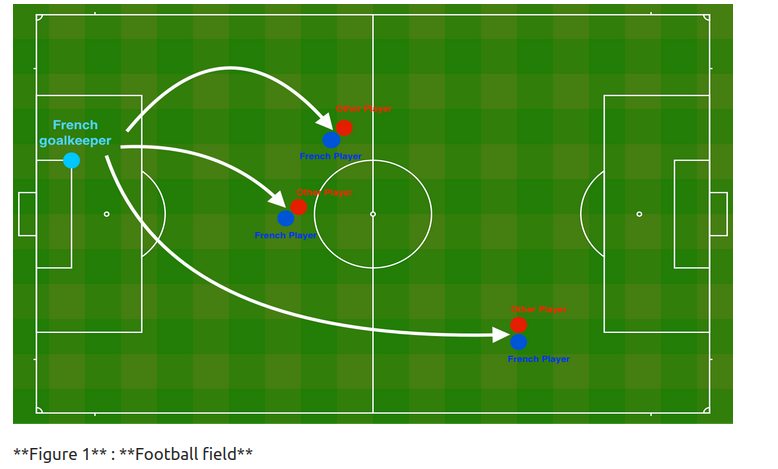

The goal keeper kicks of the ball in the air, the players of each         team are figting to hit the ball with their head. They give as the  following 2D dataset from Frace's past 10 games.


In [2]:
train_X, train_Y, test_X, test_Y = load_2D_dataset()

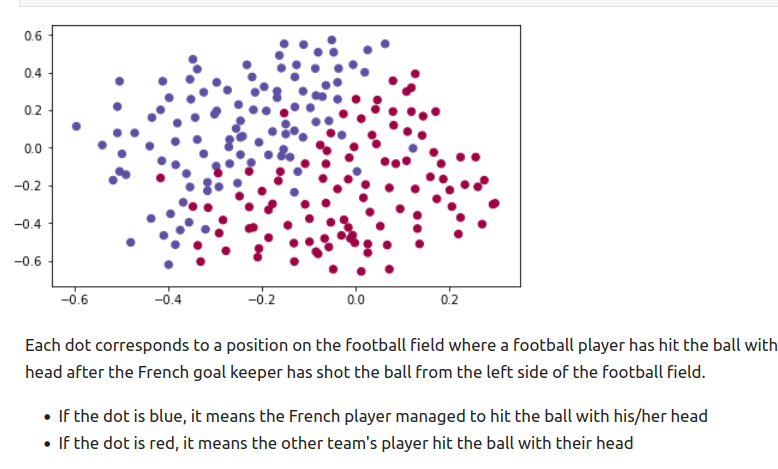

**Our goal** Use a deep learning model to find the position on the field where the goalkeeper should kick the ball.

**Analysis of the dataset** This dataset is little noisy, but it looks like a diagonal line seperating the upper left half (blue) from the lower right half (red) would work well.

We first try a non-regularized model. Then we'll learn how to regularize it and decide which model we choose to solve the Frech Football Corporation's problem.


## 1 - Non regularized model
We will use the following neural network (already implemented for us below). This model can be used:

* in regularization mode -- by setting the `lambd` input to a non-zero value. We use `"lambd"` instead of `"lambda"` because "lambda" is a reserved keyword in Python.
* in dropout mode -- by setting the `keep_prob` to a value less than one

We try the model without any regularization . Then we implement
* L2 Regularization - functions `"compute_cost_with_regularization()"` and `"backward_propagation_with_reqularization()"`
* Dropout - functions : `"forward_propagation_with_dropout()`" and `"backward_propagtion_with_dropout()"`

IN each part we'll run this model with the correct inputs so that it calls the functions we've implemented .

In [3]:
def model(X, Y, learning_rate = 0.3, num_iterations = 30000, print_cost = True, lambd = 0, keep_prob = 1):
  """
  Implements a three layer-neural network: LINEAR->RELU->LINEAR->RELU->LINEAR->SIGMOID.

  Arguments:
  X -- input data, of shape (input size, number of examples)
  Y -- true "label" vector (1 for the blue dot /0 for red dot), of shpae (output size, number of examples)
  learning rate -- learing_rate of the optimization.
  num_iterations --- If true, print the cost every 10000  iterations
  lambd -- reqularization of keeping  a neuron active during drop-out , scalar
  keep_prob -- probability of keeping a neuron active during drop-out , scalar.

  Returns :
  parameters - parameters learned by the model. They can then be used to  predict.

  """

  grads = {}
  costs = []            # to keep track of the cost
  m = X.shape[1]        # number of examples
  layers_dims = [X.shape[0], 20, 3, 1]

  # Inittialize the parameters dictionary.
  parameters = initialize_parameters(layers_dims)

  # Loop  (gradient descent)

  for i in range(0, num_iterations):

    # Forward propagation: Linear->RELU->Linear->RELU->Linear->Sigmoid
    if keep_prob == 1:
      a3, cache = forward_propagation(X, parameters)
    elif keep_prob < 1:
      a3, cache = forward_propagation_with_dropout(X, parameters, keep_prob)

    # Cost function
    if lambd == 0:
      cost = compute_cost(a3, Y)
    else:
      cost = compute_cost_with_regularization(a3, Y, parameters, lambd)

    # Backward propagation
    assert(lambd == 0 or keep_prob == 1)  # It is possible to use both the L2 regularization and dropout, but here we try one at a time.

    if lambd == 0 and keep_prob == 1:
      grads = backward_propagation(X, Y, cache)
    elif lambd != 0:
      grads = backward_propagation_with_regularization(X, Y, cache, lambd)
    elif keep_prob < 1:
      grads = backward_propagation_with_dropout(X, Y, cache, keep_prob)

    # Updatiing the parameters
    parameters = update_parameters(parameters, grads, learning_rate)

    # Print the loss every 10000 iterations
    if print_cost and i % 10000 == 0:
      print("Cost after iteration {}:{}".format(i, cost))
    if print_cost and i % 1000  == 0:
      costs.append(cost)
  # Plot the cost
  plt.plot(costs)
  plt.ylabel('iterations (x1,000)')
  plt.title("Learning rate  = " + str(learning_rate))
  plt.show()

  return parameters






Let train the model without any regualarization, and observe the accuracy on the train/test sets.


Cost after iteration 0:0.6931494025864805
Cost after iteration 10000:0.2709291959641146
Cost after iteration 20000:0.27066866761552744


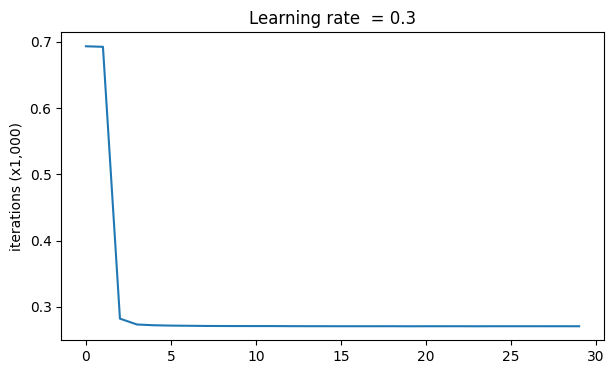

On the training set:
Accuracy: 0.88
Onthe test set:
Accuracy: 0.86


In [4]:
parameters = model(train_X, train_Y)
print("On the training set:")
predictions_train = predict(train_X, train_Y, parameters)
print("Onthe test set:")
prediction_test = predict(test_X, test_Y, parameters)

The train accuracy is 88% and test accuracy 86% . This is the **baseline model** (we observe the impact of the regularization on this model).

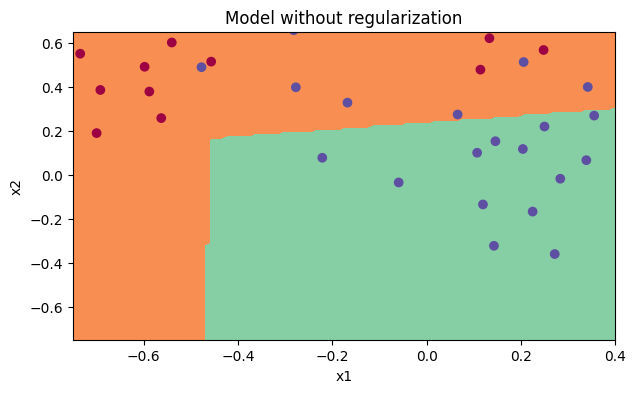

In [5]:
plt.title("Model without regularization")
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x), train_X, train_Y)



The non-regualrization model is obviously overfittng the training set. It is fitting the noisy points! Let we look at the techniques to reduce the overfitting.


## L2 Regularization

The standard way to overftting is called **L2 regualrization** .It Consists of the appropriately modifying the cost fun: from
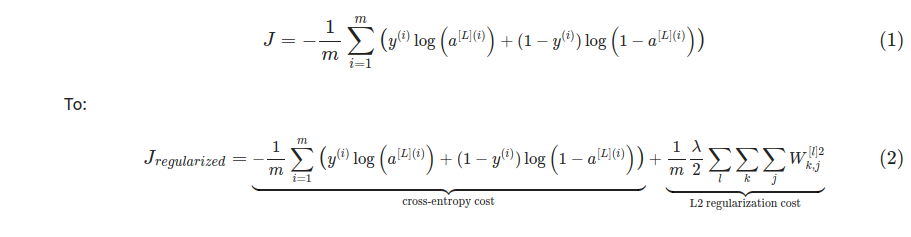

Let's modify the cost and observe the consequences.

IMplements the `compute_cost_with_regularization()` which computes the cost given by the formula (2).



In [6]:
def compute_cost_with_regularization(A3, Y, parameters, lambd):
  """
  Implementation of  the cost fun: with L2 regularization . The formual (2).

  Arguements:
  A3:  post-activation,output of forward propagation, of shape (output size, number of examples)
  Y -- "true" labels vector, of shape (output size, number of examples)
  parameters -- python dictionary containing parameters of the model

  Returns :
  cost- value of the regularized fun( formula (2))
  """

  m = Y.shape[1]
  W1 = parameters["W1"]
  W2 = parameters["W2"]
  W3 = parameters["W3"]

  cross_entropy_cost = compute_cost(A3, Y)

  L2_regularization_cost = lambd * (np.sum(np.square(W1)) + np.sum(np.square(W2)) + np.sum(np.square(W3))) / (2* m)

  cost = cross_entropy_cost + L2_regularization_cost

  return cost




In [7]:
A3, Y_asses, parameters = compute_cost_with_regularization_test_case()

print("cost = " + str(compute_cost_with_regularization(A3, Y_asses, parameters, lambd=0.1)))


cost = 1.8670186402167765


Because we changed the cost, we have to change the backward propaation as well. All the gradients have to be computed w.r.t this new cost.



Exercise: Implement the changes needed in backward propagation to take into account regularization. The changes only concern dW1, dW2 and dW3. For each, you have to add the regularization term's gradient $\frac{d}{dW}\left(\frac{\lambda}{2m}\|W\|^2\right)=\frac{\lambda}{m}W$


In [8]:
# backward propagation with regularization..

def backward_propagation_with_regularization(X, Y, cache, lambd):
  """
  Implements the backward propagation of the baseline model to which we added the L2 regularization.

  Args:
  X -- input dataset, of shape (input size, number of examples)
  Y -- "true" labels vector, of shape (output size, number of examples)
  cache -- cache output from forward propagation()
  lambd -- regualrizaton hyperparameters , scalar

  Returns :
  gradients -- A dict: with gradients w.r.t each parameter, activation and pre-activation varialbes.
  """
  m = X.shape[1]

  (Z1, A1, W1, b1, Z2, A2,W2, b2, Z3, A3, W3, b3) = cache

  dZ3 = A3 - Y

  dW3 = 1. / m * np.dot(dZ3, A2.T) + (lambd * W3 ) / m

  db3 = 1. / m* np.sum(dZ3, axis=1, keepdims=True)

  dA2 = np.dot(W3.T, dZ3)
  dZ2 = np.multiply(dA2, np.int64(A2 > 0))

  dW2 = 1. / m * np.dot(dZ2, A1.T) + (lambd * W2) / m

  db2 = 1.  / m* np.sum(dZ2,axis=1, keepdims=True)

  dA1 = np.dot(W2.T, dZ2)

  dZ1 = np.multiply(dA1, np.int64(A1 > 0))

  dW1 = 1. / m * np.dot(dZ1, X.T) + (lambd * W1) / m

  db1 = 1. / m * np.sum(dZ1, axis=1, keepdims=True)

  gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3, "dA2": dA2,
               "dZ2": dZ2, "dW2": dW2, "db2": db2, "dA1": dA1,
               "dZ1": dZ1, "dW1": dW1, "db1": db1}

  return gradients


In [9]:
X_asses , Y_asses , cache = backward_propagation_with_regularization_test_case()

grads = backward_propagation_with_regularization(X_asses, Y_asses, cache, lambd=0.7)

print("dW1 = " + str(grads["dW1"]))
print("dW2 = " + str(grads["dW2"]))
print("dW3 = " + str(grads["dW3"]))


dW1 = [[-0.15398478 -0.02413995 -0.12290018]
 [ 0.00590992  0.08159413 -0.15408668]
 [-0.23048309  0.72744474 -0.26408813]
 [ 0.62936885 -0.76383683  0.45210331]
 [-0.13100772 -0.03750433  0.07424977]
 [-0.09683251 -0.05554549 -0.09620418]
 [-0.44711824  0.37188807 -0.29772345]
 [ 0.34681586 -0.68925654  0.68206754]
 [ 0.91811125 -1.18053436  0.60863331]
 [-0.10460216  0.23694364  0.00711309]
 [ 0.39321555 -0.65812499  0.72776058]
 [-0.05180956  0.10618494 -0.04789061]
 [ 0.15279405 -0.4463213   0.13301467]
 [-0.01092392  0.07684791  0.14146035]
 [ 0.73871142 -0.7557526   0.69557713]
 [-0.10561571  0.17540154  0.07181017]
 [-0.041733    0.06839254 -0.01058004]
 [-0.43239347  0.9848965  -0.24944468]
 [-0.12023797 -0.30882831 -0.00287172]
 [ 0.02937139  0.12065631  0.0533153 ]]
dW2 = [[-0.28310817 -0.04286856  0.26281142  0.43835864  0.10668157 -0.03112594
  -0.00896976  0.08784066  0.1009282   0.02776196  0.32541103 -0.07602515
   0.24569853  0.05545748  0.53305994  0.1678485   0.025921

Let run the model with L2 regularization $( λ = 0.7).$ The `model()` funtion will call.
* `compute_cost_with_regularization` instead of the `compute_cost`

* `backward_proapgation_with_regularization` instead of the `backward_propagation`

Cost after iteration 0:0.6931698482497224
Cost after iteration 10000:0.6931471805601344
Cost after iteration 20000:0.6931471805599452


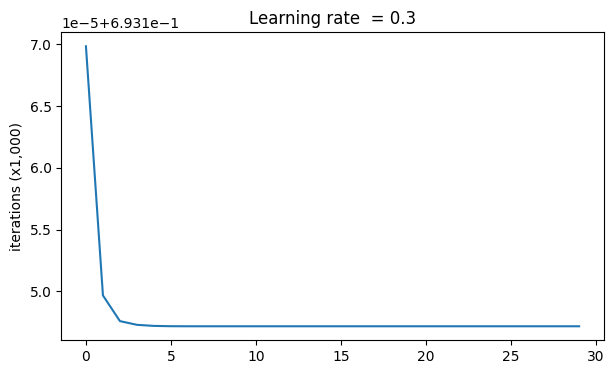

On the train set: 
Accuracy: 0.5
On the test set
Accuracy: 0.5


In [10]:
parameters = model(train_X, train_Y, lambd=0.7)

print("On the train set: ")
predictions_train = predict(train_X, train_Y, parameters)
print("On the test set")
predictions_test = predict(test_X, test_Y, parameters)

Wow our model has a little ackward accuray but still we saved the Frech Football team.

We're not overfitting the model anymore.
Let plot the decision boundary.


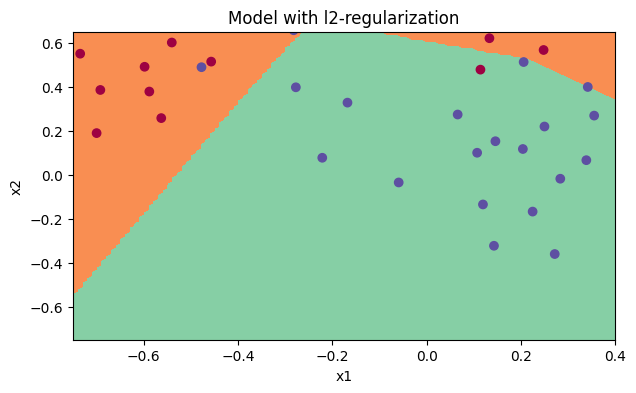

In [23]:
plt.title("Model with l2-regularization")
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])

plot_decision_boundary(lambda x: predict_dec(parameters, x), train_X, train_Y)
# plot_decision_boundary(lambda x: predict_dec(parameters, x), train_X, train_Y)


*observations:
* The value of $$ λ $$ is a hyperparameter that you can tune using a dev set.
* L2 regularization makes the decision boundary smoother. If $ λ$ is too large, it is also possible to "oversmooth" the resulting model with high bias.

**What is L2-regularization actually doing?:**
L2-regularization relies on the assumption that a model with small weights is simpler than a model with large weights. Thus, by penalizing the square values of the weights in the cost function you drive all the weights to smaller values. It becomes too costly for the cost to have large weights! This leads to a smoother model in which the output changes more slowly as the input changes.


**Summary**
The cost computation: - A regularization term is added to the cost - The backpropagation function: - There are extra terms in the gradients with respect to weight matrices - Weights end up smaller ("weight decay"): - Weights are pushed to smaller values.

## Dropout
Is another widely used regularization technique that is specific to deep learning. **It randomly shuts down some neurons in each iteration**.


At each iteration, you shut down (= set to zero) each neuron of a layer with probability `1- keep_probs`  or keep it with probability `keep_probs` (50% here). The dropped neurons don't contribute to the training in both the forward and backward propagations of the iteration.  : Drop-out on the first and third hidden layers.
layer: we shut down on average 40% of the neurons.1_st layer: we shut down on average 20% of the neurons.

When you shut some neurons down, you actually modify your model. The idea behind drop-out is that at each iteration, you train a different model that uses only a subset of your neurons. With dropout, your neurons thus become less sensitive to the activation of one other specific neuron, because that other neuron might be shut down at any time.

## Forward Propagation with Dropout
We implement Forward propagation with dropout, We use 3 layer neural network, and will add dropout to the first and second hidden layers. We will not apply dropout to the input layer or output layer.
Instructions: We would like to shut down some neurons in the first and second layers. To do that, you are going to carry out 4 Steps:


1. Creating a variable $d^{[1]}$ with  the same shape as $a^{[1]}  using np.random.rand() to randomly get numbers between 0 and 1. Here, you will use a vectorized implementation, so create a random matrix D^{ }, d^{ }, \dots, d^{[1](m)} \big], \text{ of the same dimension as } A^{[1]}.

2. Set each entry of $D^{[1]}$ to be 0 with probability (1-keep_prob) or 1 with probability (keep_prob), by thresholding values  in  $D^{[1]}$ appropriately. Hint: to set all the entries of a matrix X to 0 (if entry is less than 0.5) or 1 (if entry is more than 0.5) you would do: X = (X < 0.5). Note that 0 and 1 are respectively equivalent to False and True.

3. Set $A^{[1]} to A^{[1]} * D^{[1}]$ . (You are shutting down some neurons). You can think of as a mask, so that when it is multiplied with another matrix, it shuts down some of the values.

4. Divide $A^{[1]}$ by `keep_prob`.     By doing this you are assuring that the result of the cost will still have the same expected value as without drop-out. (This technique is also called inverted dropout.)



In [14]:
# forward_propagation_with_dropout

def forward_propagation_with_dropout(X, parameters, keep_prob=0.5):
  """
  Implements the forward propagation: LINEAR-> RELU -> DROPOUT -> LINEAR -> RELU -> DROPOUT -> LINEAR -> SIGMOID

  Arguments-
  X -- input dataset, of shape (2, number of examples)
  parameters -- python dictionary containing the parameters "W1", "b1", "W2", "b2", "W3", "b3"
                W1 - weight matrix of shape (20, 2)
                b1 - bias vector of shape (20, 1)
                W2 - weight matrix of shape (3, 20)
                b2 - bias vector of shape (3, 1)
                W3 - weight matrix of shape (1, 3)
                b3 - bias vector of shape (1, 1)

  keep_prob - probability of keeping a neuron active during drop-out scalar

  Returns -
  A3 -- last activation value, output of the forward propagation, of shape (1, 1)
  cache -- tuple , information stored for computing the backward propagation
  """

  np.random.seed(1)

  W1 = parameters["W1"]
  b1 = parameters["b1"]
  W2 = parameters["W2"]
  b2 = parameters["b2"]
  W3 = parameters["W3"]
  b3 = parameters["b3"]

  # LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID
  Z1 = np.dot(W1, X) + b1
  A1 = relu(Z1)
  # Steps 1 to 4 ....as described above.
  D1 = np.random.rand(A1.shape[0], A1.shape[1])   # initializing the matric D1 = np.random.rand(... , ...)

  D1 = D1 < keep_prob # Convert entries of D1 to 0 or 1 (using keep_prob as the threshold)
  A1 = A1 * D1    # Shut down some neurons of A1
  A1 = A1 / keep_prob    # Scale the value of neuron that haven't shut down
  Z2 = np.dot(W2, A1) + b2

  A2 = relu(Z2)
  D2 = np.random.rand(A2.shape[0], A2.shape[1])
  D2 = D2 < keep_prob
  A2 = A2 * D2
  A2 = A2 / keep_prob
  Z3 = np.dot(W3, A2) + b3
  A3 = sigmoid(Z3)

  cache = (Z1, A1, D1, W1, b1, Z2, A2, D2, W2, b2, Z3, A3, W3, b3)

  return A3, cache






In [15]:
X_assess, parameters = forward_propagation_with_dropout_test_case()

A3, cache = forward_propagation_with_dropout(X_assess, parameters, keep_prob=0.7)
print ("A3 = " + str(A3))

A3 = [[1.02706845e-06 5.00000000e-01 5.00000000e-01 5.00000000e-01
  5.00000000e-01]]


## Backward propagation with dropout

Now we implement backpropagation with dropout . As before we train 3 layer networks. Add dropout to the first and second hidden layers , using masks $D^{[1]} and D^{[2]}$  stored   in the cache.

**Backpropagation with dropout** is really easy. We need to carry out 2 steps.
1. We had previously shut down some neurons during forward propagation, by applying a mask $D^{[1]}$ to `A1`. In backpropagation, you will have to shut down the same neurons, by reapplying the same mask$D^{[1]}$  to `dA1`.
2. During forward propagation, we had divided `A1` by keep_prob. In backpropagation, we'll therefore have to divide `dA1` by `keep_prob` again (the calculus interpretation is that if  $A^{[1]}$ is scaled by keep_prob, then its derivative  $dA^{[1]}$ is also scaled by the same keep_prob).

In [18]:
# backward_propagation_with_dropout

def backward_propagation_with_dropout(X, Y, cache, keep_prob):
  """
  Implements the backward propagation of our baseline model to which we added dropout.

  Arguments:
  X -- input dataset, of shape (2, number of examples)
  Y -- "true" labels vector of shape (output size, number of examples)
  cache -- cache output from forward_propagation_with_dropout()
  keep_prob -- probability of keeping a neuron active during the drop-out , scalar.

  Returns --
    gradients -- A dictionary with the gradients with respect to each parameter, activation and pre-activation variables
  """

  m = X.shape[1]

  (Z1, A1, D1, W1, b1, Z2, A2, D2, W2, b2,Z3, A3, W3, b3) = cache

  dZ3 = A3 - Y
  dW3 = 1. / m * np.dot(dZ3, A2.T)
  db3 = 1. / m * np.sum(dZ3, axis=1, keepdims=True)
  dA2 = np.dot(W3.T, dZ3)
  dA2 = dA2 * D2     # Apply mask D2 to shut down the same neurons as during the forward propagation
  dA2 = dA2 / keep_prob     # Scale the value of the neurons that haven't been shut down.

  dZ2 = np.multiply(dA2, np.int64(A2 > 0))
  dW2 = 1. / m * np.dot(dZ2, A1.T)
  db2 = 1.  / m * np.sum(dZ2, axis=1, keepdims=True)

  dA1 = np.dot(W2.T, dZ2)
  dA1  = dA1 * D1   # Apply mask D1 to shut down the same neurons as during the forward propagation
  dA1 = dA1 / keep_prob
  dZ1 = np.multiply(dA1, np.int64(A1 > 0))

  dW1 = 1. / m * np.dot(dZ1, X.T)
  db1 = 1. / m * np.sum(dZ1, axis=1, keepdims=True)

  gradients = {"dZ3":dZ3, "dW3":dW3, "db3":db3, "dA2": dA2,
               "dZ2": dZ2, "dW2": dW2, "db2": db2, "dA1": dA1,
               "dZ1": dZ1, "dW1": dW1, "db1": db1}



  return gradients

In [19]:
X_asses,Y_asses, cache = backward_propagation_with_dropout_test_case()

gradients = backward_propagation_with_dropout(X_asses, Y_asses, cache, keep_prob=0.8)
print("dA1 = " + str(gradients["dA1"]))
print ("dA2 = " + str(gradients["dA2"]))

dA1 = [[-9.85083918e-05  0.00000000e+00 -3.14542248e-06  0.00000000e+00
  -0.00000000e+00]
 [-0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.39845198e-05]
 [ 4.03334989e-05  0.00000000e+00 -0.00000000e+00  0.00000000e+00
  -0.00000000e+00]
 [ 1.12087077e-05  0.00000000e+00  2.52154495e-05  0.00000000e+00
   2.52154178e-05]
 [ 0.00000000e+00  0.00000000e+00 -2.83889800e-05  0.00000000e+00
  -2.83889442e-05]
 [-1.08303702e-05  0.00000000e+00  1.81847297e-05  0.00000000e+00
   0.00000000e+00]
 [-0.00000000e+00  0.00000000e+00 -4.98007584e-05  0.00000000e+00
  -4.98006957e-05]
 [ 0.00000000e+00  0.00000000e+00 -0.00000000e+00  0.00000000e+00
  -0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -2.41408531e-05  0.00000000e+00
  -0.00000000e+00]
 [ 9.65986291e-06  0.00000000e+00  4.45300917e-05  0.00000000e+00
   4.45300356e-05]
 [ 5.79732136e-06  0.00000000e+00 -6.88878771e-06  0.00000000e+00
  -6.88877904e-06]
 [-3.26702718e-05  0.00000000e+00 -3.01184491e-05  0.000000

Let's now run the model with dropout (keep_prob = 0.86). It means at every iteration you shut down each neurons of layer 1 and 2 with 24% probability. The function model() will now call:

* `forward_propagation_with_dropout` instead of `forward_propagation.`
* `backward_propagation_with_dropout` instead of `backward_propagation.`

Cost after iteration 0:0.6931493149030566


/content/reg_utils.py:118: RuntimeWarning: divide by zero encountered in log
  cost = -np.sum(Y * np.log(A3) + (1 - Y) * np.log(1 - A3)) / m
/content/reg_utils.py:118: RuntimeWarning: invalid value encountered in multiply
  cost = -np.sum(Y * np.log(A3) + (1 - Y) * np.log(1 - A3)) / m


Cost after iteration 10000:nan
Cost after iteration 20000:nan


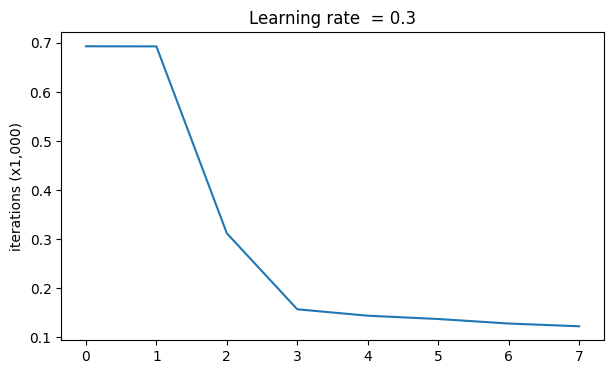

On the train set: 
Accuracy: 0.94
On the test set: 
Accuracy: 0.92


In [20]:
parameters = model(train_X, train_Y, keep_prob=0.86, learning_rate=0.3)

print("On the train set: ")
predictions_train = predict(train_X, train_Y, parameters)
print("On the test set: ")
prediction_test = predict(test_X, test_Y, parameters)

Dropout works great! The test accuracy has increased again (to 92%)! Your model is not overfitting the training set and does a great job on the test set. The French football team will be forever grateful to you!

Let see the decision boundary plot


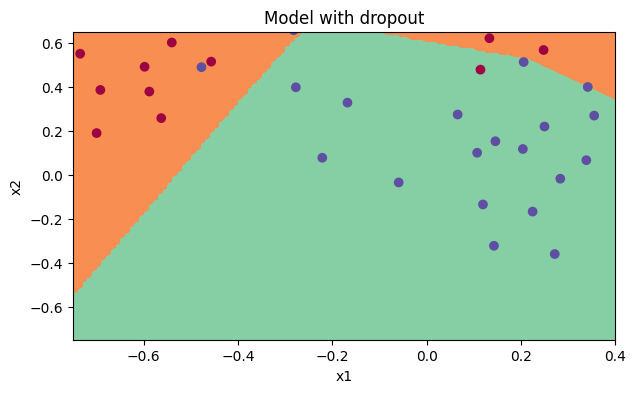

In [24]:
plt.title("Model with dropout")
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
# plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)
plot_decision_boundary(lambda x: predict_dec(parameters, x), train_X, train_Y)


**Notes **
* A **common mistake** when using the dropout is to use it both  in training and testing . We should use dropout (randomly eliminate nodes) only in training.


## Summary
Dropout is a regularization technique. - You only use dropout during training. Don't use dropout (randomly eliminate nodes) during test time. - Apply dropout both during forward and backward propagation. - During training time, divide each dropout layer by keep_prob to keep the same expected value for the activations. For example, if keep_prob is 0.5, then we will on average shut down half the nodes, so the output will be scaled by 0.5 since only the remaining half are contributing to the solution. Dividing by 0.5 is equivalent to multiplying by 2. Hence, the output now has the same expected value. You can check that this works even when keep_prob is other values than 0.5.



Note that regularization hurts training set performance! This is because it limits the ability of the network to overfit to the training set. But since it ultimately gives better test accuracy, it is helping your system.

*  Regularization will help you reduce overfitting. - Regularization will drive your weights to lower values. - L2 regularization and Dropout are two very effective regularization techniques.
